In [7]:
using SpecialFunctions
# using StatsPlots
using CairoMakie
using FileIO
using DataFrames
using DataFramesMeta
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/hmm_independentsamedist.jl")
include("$(filepath)/code/qlearner.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

In [8]:
data = Dict()
for animal in animals
    data[animal] = load_animal(animal, "..")
end

In [9]:
# Correspondence of sessions and days
animal_session_info = Dict()
for animal in animals
    firstrows = combine(first, groupby(load_animal(animal, ".."), :daysessionnum))[:, [:date, :daysessionnum, :daynum, :session]]
    nrows = combine(nrow, groupby(load_animal(animal, ".."), :daysessionnum))
    animal_session_info[animal] = innerjoin(firstrows, nrows, on=:daysessionnum)
end

In [10]:
# Correspondence of sessions and days
animal_day_info = Dict()
for animal in animals
    firstrows = combine(first, groupby(load_animal(animal, ".."), :daynum))[:, [:date, :daynum, :session]]
    nrows = combine(nrow, groupby(load_animal(animal, ".."), :daynum))
    animal_day_info[animal] = innerjoin(firstrows, nrows, on=:daynum)
end

# Peri-switch uncertainty

Possible uncertainty measures:
- Global state entropy
    - `state_entropy`
- Global reward entropy
    - `reward_entropy`
- Local reward entropy
    - `reward_entropy_current_leaf`
    - `reward_entropy_pair_prev_leaf`
    - `reward_entropy_pair_current_leaf`

First, versions without γ2

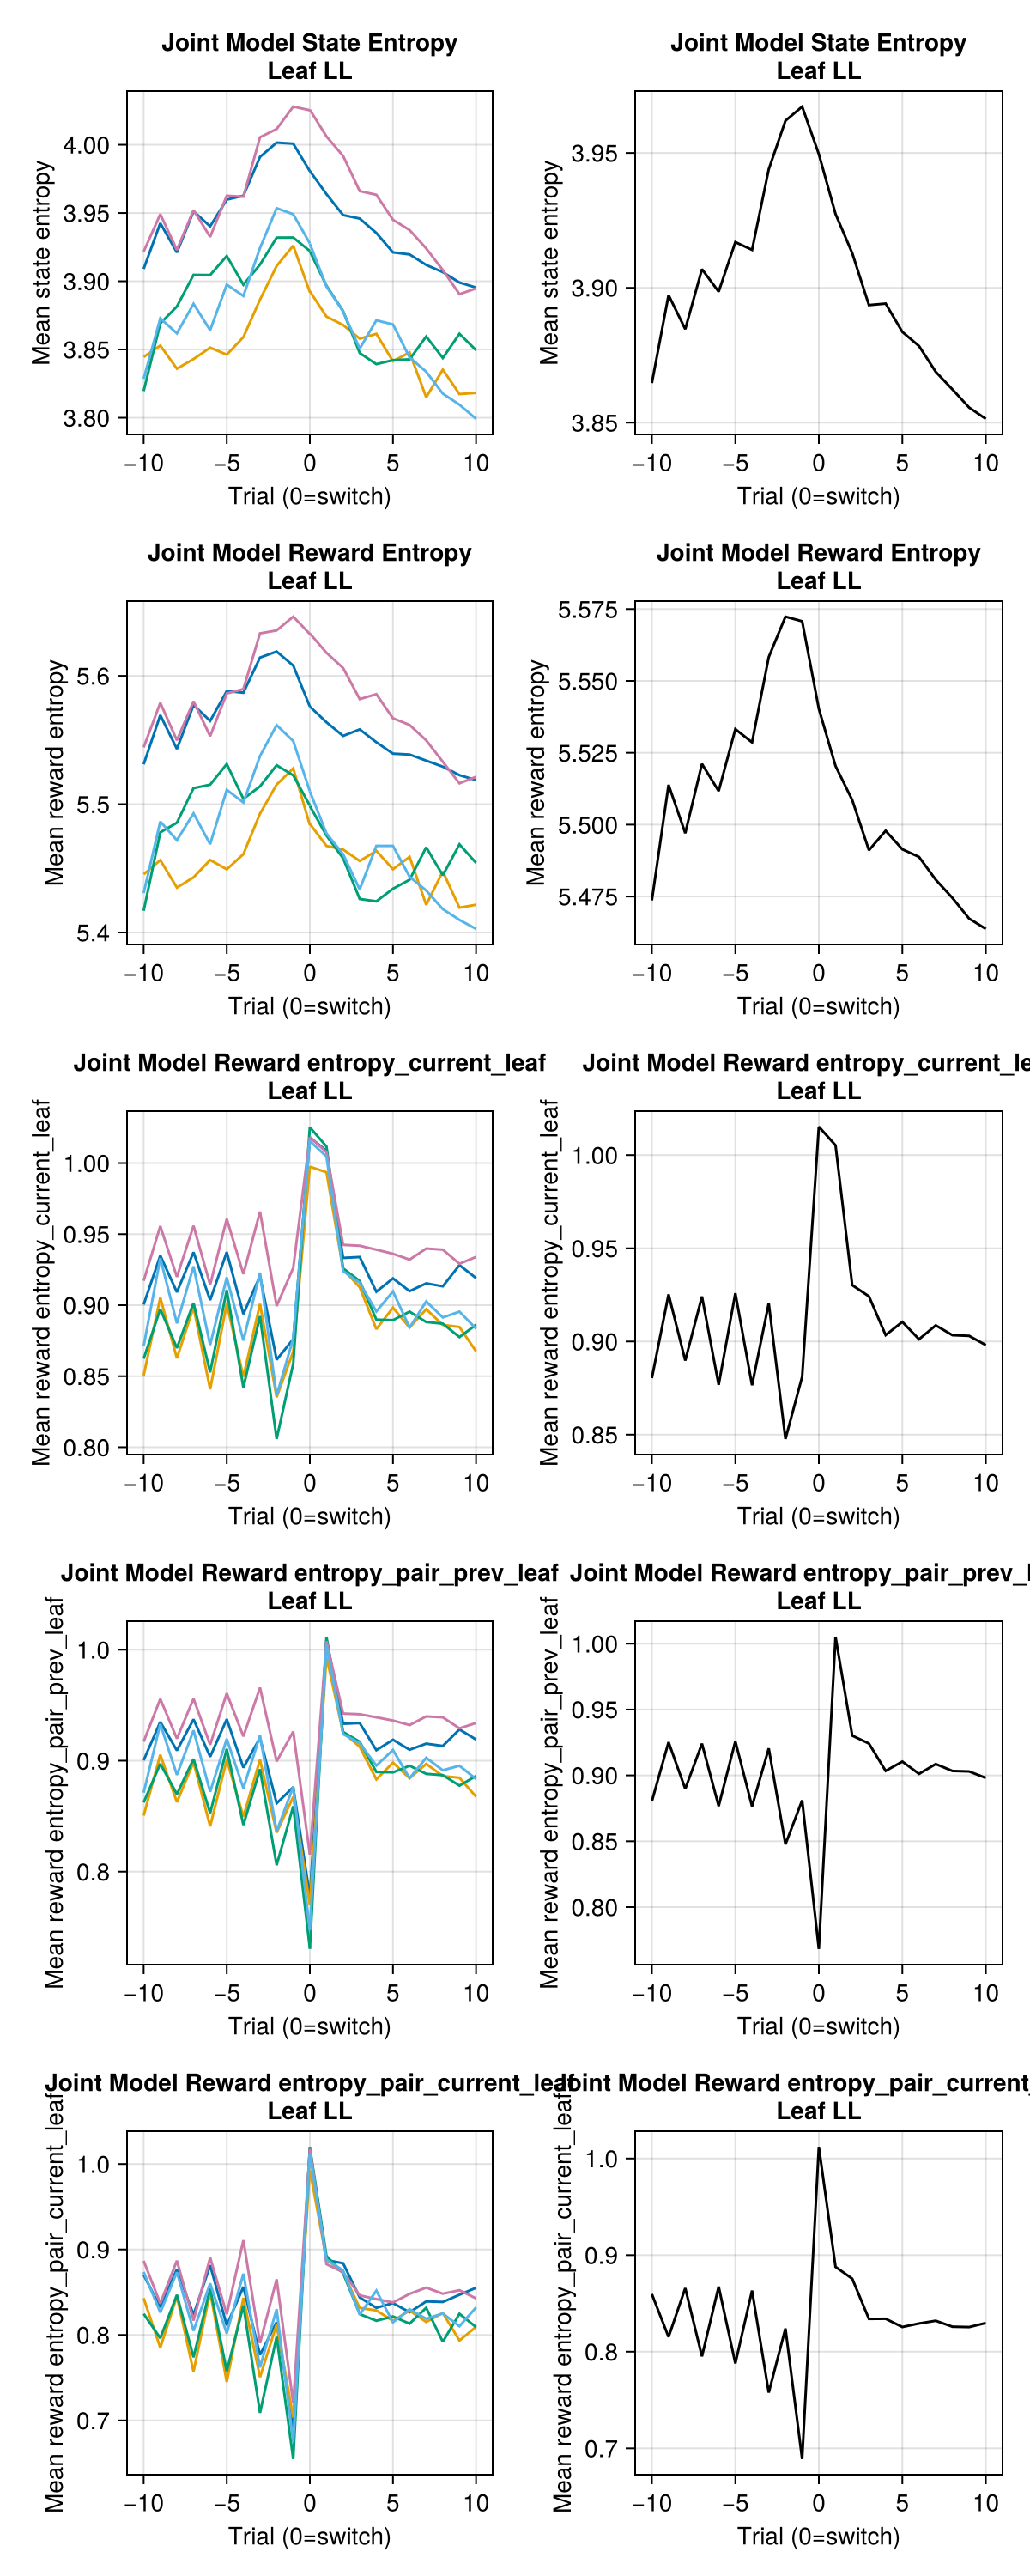

In [11]:
f = Figure(size=(600,1500))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = true
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = false
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean state entropy", xlabel="Trial (0=switch)", title="Joint Model State Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    state_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :state_entropy => mean => :state_entropy)
    state_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :state_entropy => mean => :state_entropy)

    lines!(-state_entropy_by_day_q1_pre.n_pre_switch, state_entropy_by_day_q1_pre.state_entropy, color=colors[i], label=animal)
    lines!(state_entropy_by_day_q1_post.n_post_switch, state_entropy_by_day_q1_post.state_entropy, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean state entropy", xlabel="Trial (0=switch)", title="Joint Model State Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
state_entropy_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    state_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :state_entropy => mean => :state_entropy)
    state_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :state_entropy => mean => :state_entropy)

    state_entropy_all[11:-1:1] .+= state_entropy_by_day_q1_pre.state_entropy
    state_entropy_all[12:21] .+= state_entropy_by_day_q1_post.state_entropy[2:end]
end
lines!(-10:10, state_entropy_all ./ length(animals), color="black")

ax3 = Axis(f[2,1], ylabel="Mean reward entropy", xlabel="Trial (0=switch)", title="Joint Model Reward Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy => mean => :reward_entropy)
    reward_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy => mean => :reward_entropy)

    lines!(-reward_entropy_by_day_q1_pre.n_pre_switch, reward_entropy_by_day_q1_pre.reward_entropy, color=colors[i], label=animal)
    lines!(reward_entropy_by_day_q1_post.n_post_switch, reward_entropy_by_day_q1_post.reward_entropy, color=colors[i])
end

ax4 = Axis(f[2,2], ylabel="Mean reward entropy", xlabel="Trial (0=switch)", title="Joint Model Reward Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy => mean => :reward_entropy)
    reward_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy => mean => :reward_entropy)

    reward_entropy_all[11:-1:1] .+= reward_entropy_by_day_q1_pre.reward_entropy
    reward_entropy_all[12:21] .+= reward_entropy_by_day_q1_post.reward_entropy[2:end]
end
lines!(-10:10, reward_entropy_all ./ length(animals), color="black")

ax5 = Axis(f[3,1], ylabel="Mean reward entropy_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)
    reward_entropy_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)

    lines!(-reward_entropy_current_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_current_leaf_by_day_q1_pre.reward_entropy_current_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_current_leaf_by_day_q1_post.n_post_switch, reward_entropy_current_leaf_by_day_q1_post.reward_entropy_current_leaf, color=colors[i])
end

ax6 = Axis(f[3,2], ylabel="Mean reward entropy_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_current_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)
    reward_entropy_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)

    reward_entropy_current_leaf_all[11:-1:1] .+= reward_entropy_current_leaf_by_day_q1_pre.reward_entropy_current_leaf
    reward_entropy_current_leaf_all[12:21] .+= reward_entropy_current_leaf_by_day_q1_post.reward_entropy_current_leaf[2:end]
end
lines!(-10:10, reward_entropy_current_leaf_all ./ length(animals), color="black")

ax7 = Axis(f[4,1], ylabel="Mean reward entropy_pair_prev_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_prev_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_prev_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)
    reward_entropy_pair_prev_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)

    lines!(-reward_entropy_pair_prev_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_pair_prev_leaf_by_day_q1_pre.reward_entropy_pair_prev_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_pair_prev_leaf_by_day_q1_post.n_post_switch, reward_entropy_pair_prev_leaf_by_day_q1_post.reward_entropy_pair_prev_leaf, color=colors[i])
end

ax8 = Axis(f[4,2], ylabel="Mean reward entropy_pair_prev_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_prev_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_pair_prev_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_prev_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)
    reward_entropy_pair_prev_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)

    reward_entropy_pair_prev_leaf_all[11:-1:1] .+= reward_entropy_pair_prev_leaf_by_day_q1_pre.reward_entropy_pair_prev_leaf
    reward_entropy_pair_prev_leaf_all[12:21] .+= reward_entropy_pair_prev_leaf_by_day_q1_post.reward_entropy_pair_prev_leaf[2:end]
end
lines!(-10:10, reward_entropy_pair_prev_leaf_all ./ length(animals), color="black")

ax9 = Axis(f[5,1], ylabel="Mean reward entropy_pair_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)
    reward_entropy_pair_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)

    lines!(-reward_entropy_pair_current_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_pair_current_leaf_by_day_q1_pre.reward_entropy_pair_current_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_pair_current_leaf_by_day_q1_post.n_post_switch, reward_entropy_pair_current_leaf_by_day_q1_post.reward_entropy_pair_current_leaf, color=colors[i])
end

ax10 = Axis(f[5,2], ylabel="Mean reward entropy_pair_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_pair_current_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)
    reward_entropy_pair_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)

    reward_entropy_pair_current_leaf_all[11:-1:1] .+= reward_entropy_pair_current_leaf_by_day_q1_pre.reward_entropy_pair_current_leaf
    reward_entropy_pair_current_leaf_all[12:21] .+= reward_entropy_pair_current_leaf_by_day_q1_post.reward_entropy_pair_current_leaf[2:end]
end
lines!(-10:10, reward_entropy_pair_current_leaf_all ./ length(animals), color="black")

f

In [1]:
Second, versions with γ2

UndefVarError: UndefVarError: `Second` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Dates in the current active module Main

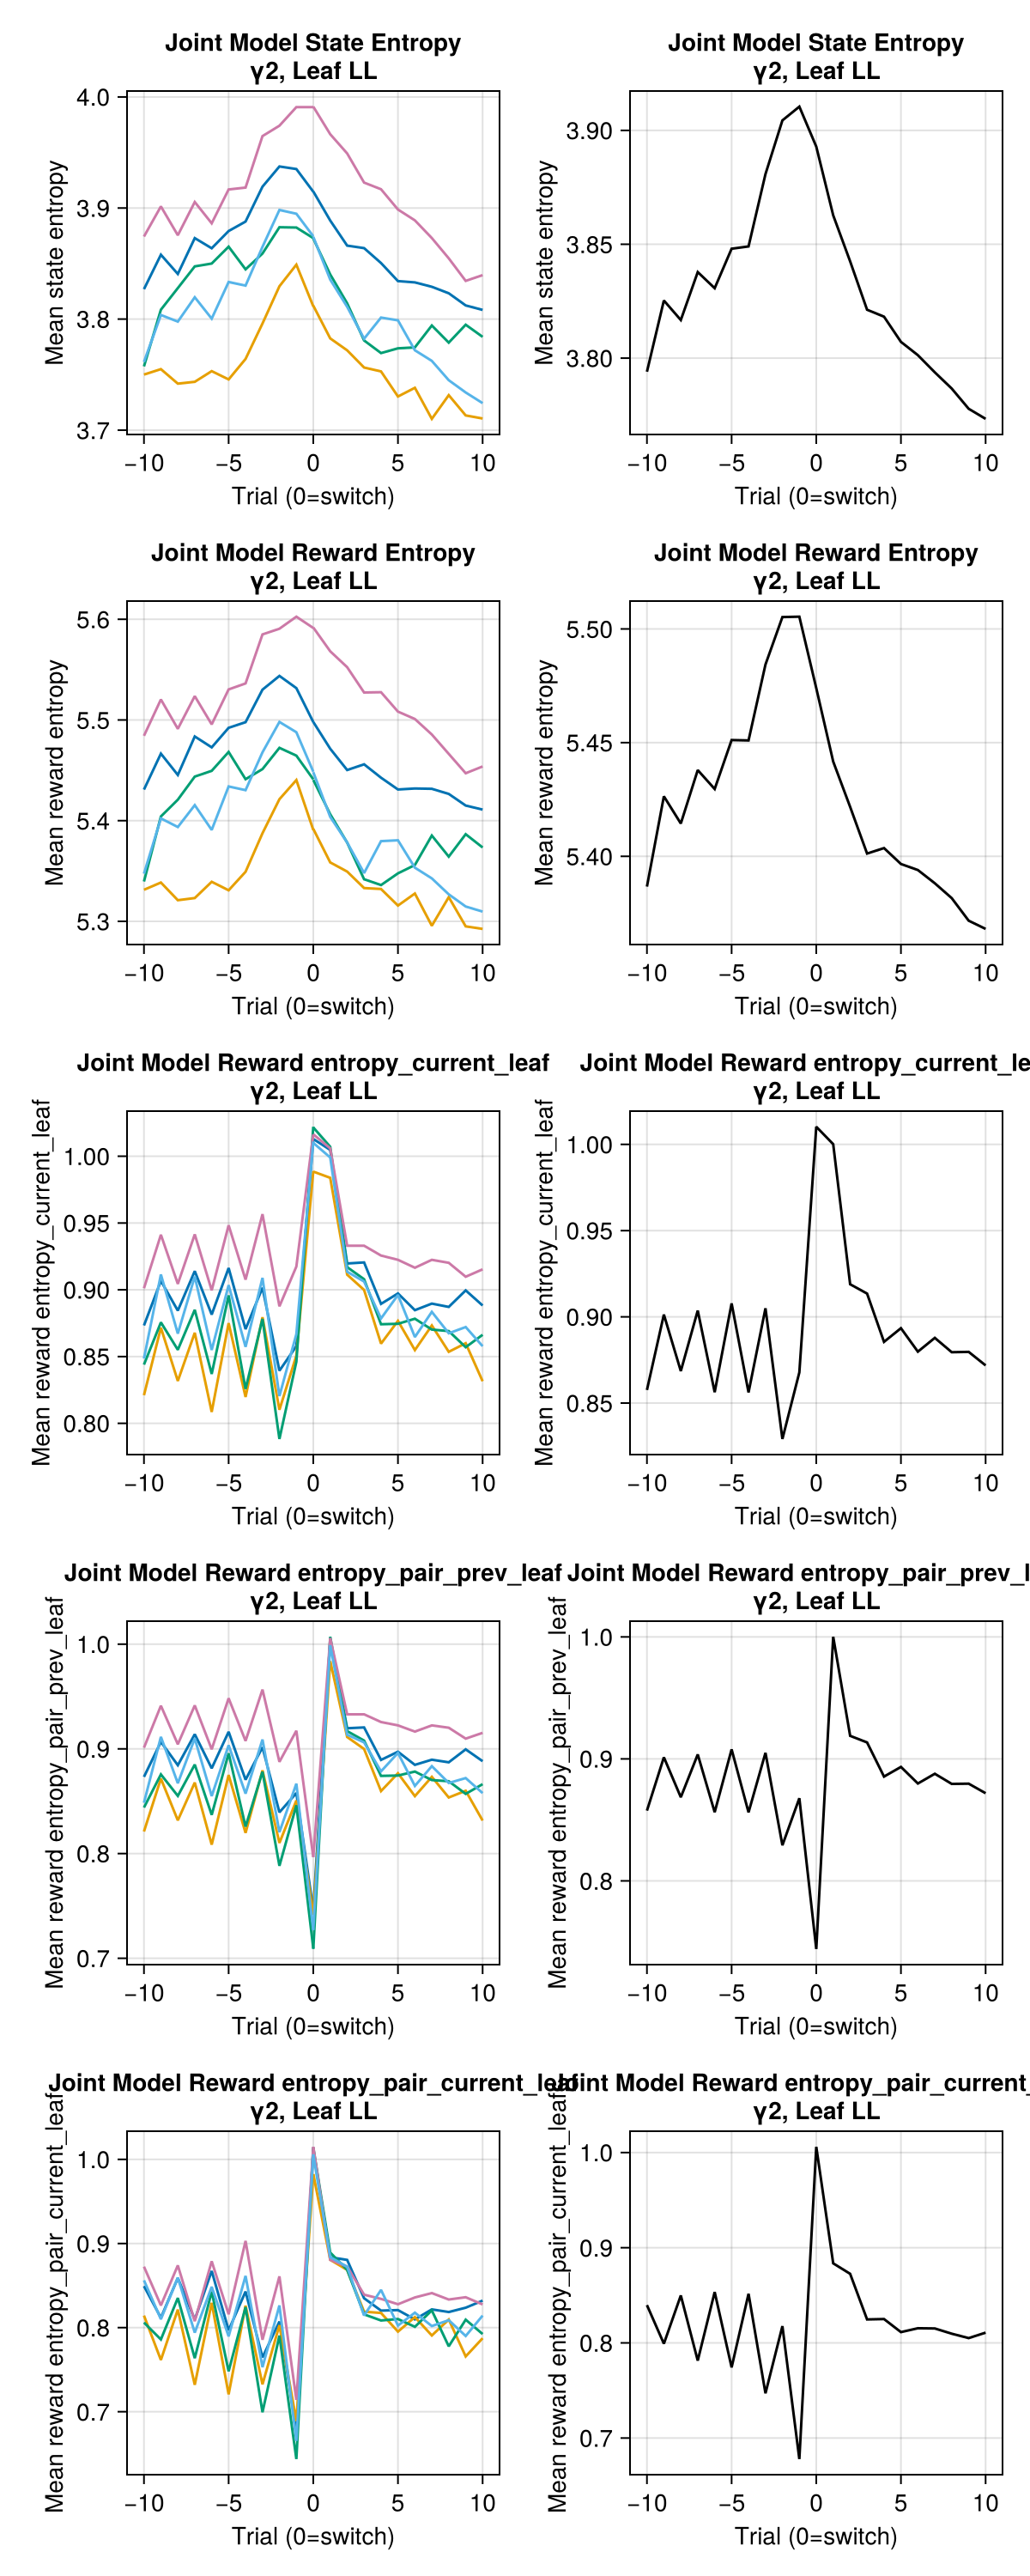

In [12]:
f = Figure(size=(600,1500))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = true
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean state entropy", xlabel="Trial (0=switch)", title="Joint Model State Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    state_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :state_entropy => mean => :state_entropy)
    state_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :state_entropy => mean => :state_entropy)

    lines!(-state_entropy_by_day_q1_pre.n_pre_switch, state_entropy_by_day_q1_pre.state_entropy, color=colors[i], label=animal)
    lines!(state_entropy_by_day_q1_post.n_post_switch, state_entropy_by_day_q1_post.state_entropy, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean state entropy", xlabel="Trial (0=switch)", title="Joint Model State Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
state_entropy_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    state_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :state_entropy => mean => :state_entropy)
    state_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :state_entropy => mean => :state_entropy)

    state_entropy_all[11:-1:1] .+= state_entropy_by_day_q1_pre.state_entropy
    state_entropy_all[12:21] .+= state_entropy_by_day_q1_post.state_entropy[2:end]
end
lines!(-10:10, state_entropy_all ./ length(animals), color="black")

ax3 = Axis(f[2,1], ylabel="Mean reward entropy", xlabel="Trial (0=switch)", title="Joint Model Reward Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy => mean => :reward_entropy)
    reward_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy => mean => :reward_entropy)

    lines!(-reward_entropy_by_day_q1_pre.n_pre_switch, reward_entropy_by_day_q1_pre.reward_entropy, color=colors[i], label=animal)
    lines!(reward_entropy_by_day_q1_post.n_post_switch, reward_entropy_by_day_q1_post.reward_entropy, color=colors[i])
end

ax4 = Axis(f[2,2], ylabel="Mean reward entropy", xlabel="Trial (0=switch)", title="Joint Model Reward Entropy\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy => mean => :reward_entropy)
    reward_entropy_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy => mean => :reward_entropy)

    reward_entropy_all[11:-1:1] .+= reward_entropy_by_day_q1_pre.reward_entropy
    reward_entropy_all[12:21] .+= reward_entropy_by_day_q1_post.reward_entropy[2:end]
end
lines!(-10:10, reward_entropy_all ./ length(animals), color="black")

ax5 = Axis(f[3,1], ylabel="Mean reward entropy_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)
    reward_entropy_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)

    lines!(-reward_entropy_current_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_current_leaf_by_day_q1_pre.reward_entropy_current_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_current_leaf_by_day_q1_post.n_post_switch, reward_entropy_current_leaf_by_day_q1_post.reward_entropy_current_leaf, color=colors[i])
end

ax6 = Axis(f[3,2], ylabel="Mean reward entropy_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_current_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)
    reward_entropy_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_current_leaf => mean => :reward_entropy_current_leaf)

    reward_entropy_current_leaf_all[11:-1:1] .+= reward_entropy_current_leaf_by_day_q1_pre.reward_entropy_current_leaf
    reward_entropy_current_leaf_all[12:21] .+= reward_entropy_current_leaf_by_day_q1_post.reward_entropy_current_leaf[2:end]
end
lines!(-10:10, reward_entropy_current_leaf_all ./ length(animals), color="black")

ax7 = Axis(f[4,1], ylabel="Mean reward entropy_pair_prev_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_prev_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_prev_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)
    reward_entropy_pair_prev_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)

    lines!(-reward_entropy_pair_prev_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_pair_prev_leaf_by_day_q1_pre.reward_entropy_pair_prev_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_pair_prev_leaf_by_day_q1_post.n_post_switch, reward_entropy_pair_prev_leaf_by_day_q1_post.reward_entropy_pair_prev_leaf, color=colors[i])
end

ax8 = Axis(f[4,2], ylabel="Mean reward entropy_pair_prev_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_prev_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_pair_prev_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_prev_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)
    reward_entropy_pair_prev_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_prev_leaf => mean => :reward_entropy_pair_prev_leaf)

    reward_entropy_pair_prev_leaf_all[11:-1:1] .+= reward_entropy_pair_prev_leaf_by_day_q1_pre.reward_entropy_pair_prev_leaf
    reward_entropy_pair_prev_leaf_all[12:21] .+= reward_entropy_pair_prev_leaf_by_day_q1_post.reward_entropy_pair_prev_leaf[2:end]
end
lines!(-10:10, reward_entropy_pair_prev_leaf_all ./ length(animals), color="black")

ax9 = Axis(f[5,1], ylabel="Mean reward entropy_pair_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)
    reward_entropy_pair_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)

    lines!(-reward_entropy_pair_current_leaf_by_day_q1_pre.n_pre_switch, reward_entropy_pair_current_leaf_by_day_q1_pre.reward_entropy_pair_current_leaf, color=colors[i], label=animal)
    lines!(reward_entropy_pair_current_leaf_by_day_q1_post.n_post_switch, reward_entropy_pair_current_leaf_by_day_q1_post.reward_entropy_pair_current_leaf, color=colors[i])
end

ax10 = Axis(f[5,2], ylabel="Mean reward entropy_pair_current_leaf", xlabel="Trial (0=switch)", title="Joint Model Reward entropy_pair_current_leaf\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
reward_entropy_pair_current_leaf_all = zeros(21)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    
    reward_entropy_pair_current_leaf_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)
    reward_entropy_pair_current_leaf_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :reward_entropy_pair_current_leaf => mean => :reward_entropy_pair_current_leaf)

    reward_entropy_pair_current_leaf_all[11:-1:1] .+= reward_entropy_pair_current_leaf_by_day_q1_pre.reward_entropy_pair_current_leaf
    reward_entropy_pair_current_leaf_all[12:21] .+= reward_entropy_pair_current_leaf_by_day_q1_post.reward_entropy_pair_current_leaf[2:end]
end
lines!(-10:10, reward_entropy_pair_current_leaf_all ./ length(animals), color="black")

f